# RNN FRED LSTM
For these exercises we're using data from the Federal Reserve Economic Database (FRED) concerning Electricity and Gas Utilities Production from January 1992 to January 2019 (325 records).

Data source: https://fred.stlouisfed.org/series/IPG2211A2N

In the exercises below you'll be asked to do the following:
* Perform standard imports, load & plot the dataset (code provided)
* Prepare data for an LSTM model
* Define the LSTM model, loss and optimization functions
* Train the model
* Evaluate the model on test data
* Plot the results

## Perform standard imports, load and plot the dataset
Run the cells below to load the libraries needed for this exercise and the Energy Production dataset, and to plot the data.

In [57]:
# standard imports
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

df = pd.read_csv('../Data/TimeSeriesData/Energy_Production.csv',index_col=0,parse_dates=True)
df.dropna(inplace=True)
print(len(df))
df.head()

325


,IPG2211A2N
DATE,
1992-01-01,85.5560
1992-02-01,80.4178
1992-03-01,74.7390
1992-04-01,69.8367
1992-05-01,67.3781


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 325 entries, 1992-01-01 to 2019-01-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   IPG2211A2N  325 non-null    float64
dtypes: float64(1)
memory usage: 5.1 KB


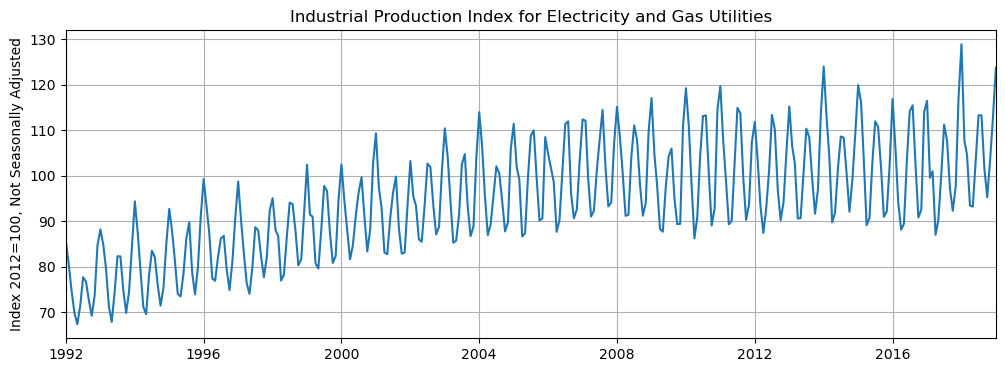

In [59]:
# Plot the data
plt.figure(figsize=(12,4))
plt.title('Industrial Production Index for Electricity and Gas Utilities')
plt.ylabel('Index 2012=100, Not Seasonally Adjusted')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['IPG2211A2N'])
plt.show()

# Prepare the data
For the first set of exercises we'll
* divide the data into train and test sets
* normalize the training set
* prepare windowed seq/label tuples for an LSTM model

## 1. Divide the data into train and test sets
Working with a window_size of 12, divide the dataset into a sequence of 313 training records (including the window), and a test set of 12 records.

In [60]:
y = df['IPG2211A2N'].values.astype(float)

test_size = 12
window_size = 12

train_set = y[:-window_size]
test_set = y[-window_size:]

In [61]:
print(f'Train: {len(train_set)}')
print(f'Test:  {len(test_set)}')

Train: 313
Test:  12


## 2. Normalize the training set
Feature scale the training set to fit within the range [-1,1].

In [62]:
scaler = MinMaxScaler(feature_range=(-1, 1))
train_norm = scaler.fit_transform(train_set.reshape(-1, 1))

In [63]:
print(f'First item, original: {train_set[0]}')
print(f'First item, scaled:  {train_norm[0]}')

First item, original: 85.556
First item, scaled:  [-0.4091274]


## 3. Prepare data for LSTM
Prepare the list of windowed sequence/label tuples to be fed into an LSTM model.

In [64]:
train_norm = torch.FloatTensor(train_norm).view(-1)

def input_data(seq,ws):
    out = []
    L = len(seq)
    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))
    return out

In [65]:
train_data = input_data(train_norm, window_size)

In [66]:
print(f'Train_data: {len(train_data)}')  # should equal 301

Train_data: 301


## 4. Define the model
Design a model that has a (1,64) LSTM layer and a (64,1) fully-connected linear layer. Be sure to initialize $h_0$ and $c_0$, and return only the last predicted value.

In [67]:
class LSTMnetwork(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, out_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size,hidden_size)
        self.linear = nn.Linear(hidden_size,out_size)
        # Initialize h0 and c0:
        self.hidden = (torch.zeros(1,1,self.hidden_size),
                       torch.zeros(1,1,self.hidden_size))

    def forward(self,seq):
        lstm_out, self.hidden = self.lstm(
            seq.view(len(seq),1,-1), self.hidden)
        pred = self.linear(lstm_out.view(len(seq),-1))
        return pred[-1]  # we only want the last value

## 5. Define loss and optimization functions
Define a loss function called "criterion" and an optimizer called "optimizer".<br>
You can use any functions you want, although we used MSELoss and Adam (learning rate of 0.001) respectively.

In [68]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)



In [69]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')
    
count_parameters(model)

   256
 16384
   256
   256
    64
     1
______
 17217


### 6. Train the model
Don't worry about tracking loss values, displaying results, or validating the test set. Just train the model through 50 epochs. We'll evaluate the trained model in the next step.<br>
OPTIONAL: print something after each epoch to indicate training progress.

In [70]:
epochs = 50

import time
start_time = time.time()

for epoch in range(epochs):
    
    # extract the sequence & label from the training data
    for seq, y_train in train_data:
        
        # reset the parameters and hidden states
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        
        y_pred = model(seq)
        
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        
    # print training result
    print(f'Epoch: {epoch+1:2} Loss: {loss.item():10.8f}')
    
print(f'\nDuration: {time.time() - start_time:.0f} seconds')

Epoch:  1 Loss: 0.01519525
Epoch:  2 Loss: 0.01065977
Epoch:  3 Loss: 0.00945098
Epoch:  4 Loss: 0.00934994
Epoch:  5 Loss: 0.00927695
Epoch:  6 Loss: 0.00720930
Epoch:  7 Loss: 0.00670043
Epoch:  8 Loss: 0.00619479
Epoch:  9 Loss: 0.01088775
Epoch: 10 Loss: 0.00525375
Epoch: 11 Loss: 0.00511767
Epoch: 12 Loss: 0.00457943
Epoch: 13 Loss: 0.00488232
Epoch: 14 Loss: 0.00602232
Epoch: 15 Loss: 0.00714736
Epoch: 16 Loss: 0.00561306
Epoch: 17 Loss: 0.00473686
Epoch: 18 Loss: 0.00871538
Epoch: 19 Loss: 0.00560086
Epoch: 20 Loss: 0.00760715
Epoch: 21 Loss: 0.00224344
Epoch: 22 Loss: 0.00111582
Epoch: 23 Loss: 0.00036301
Epoch: 24 Loss: 0.00093125
Epoch: 25 Loss: 0.00192173
Epoch: 26 Loss: 0.00295870
Epoch: 27 Loss: 0.03996477
Epoch: 28 Loss: 0.00666837
Epoch: 29 Loss: 0.00280007
Epoch: 30 Loss: 0.00202130
Epoch: 31 Loss: 0.00774793
Epoch: 32 Loss: 0.00173696
Epoch: 33 Loss: 0.00134640
Epoch: 34 Loss: 0.00241307
Epoch: 35 Loss: 0.00859760
Epoch: 36 Loss: 0.00199281
Epoch: 37 Loss: 0.00548094
E

### 9. Evaluate the model using the test set
Be sure to re-initialize the hidden parameters $h_0$ and $c_0$ before running the model.

In [71]:
future = 12
preds = train_norm[-window_size:].tolist()

model.eval()

for i in range(future):
    y_pred = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        preds.append(model(y_pred).item())
    




In [72]:
# Run the code below to check your results:
preds[-window_size:]

[0.4495193660259247,
 0.2562864422798157,
 -0.2330043911933899,
 -0.1568872630596161,
 0.37613892555236816,
 0.45704829692840576,
 0.14274054765701294,
 -0.11706577241420746,
 -0.3208234906196594,
 -0.047204434871673584,
 0.1748526692390442,
 0.5956823825836182]

## 10. Inverse transform the predicted values
Rescale the predicted values up to the original test set range.

In [73]:
true_predictions = scaler.inverse_transform(np.array(preds[-window_size:]).reshape(-1, 1))

In [74]:
true_predictions

array([[111.97183854],
       [106.02712425],
       [ 90.97433641],
       [ 93.3160418 ],
       [109.71432598],
       [112.20346233],
       [102.53394158],
       [ 94.54113004],
       [ 88.27262572],
       [ 96.69037916],
       [103.52185494],
       [116.46847066]])

## Plot the result
Plotting the true_predictions values together with the original data.

In [75]:
x = np.arange('2018-02-01','2019-02-01',dtype = 'datetime64[M]')

In [76]:
x

array(['2018-02', '2018-03', '2018-04', '2018-05', '2018-06', '2018-07',
       '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01'],
      dtype='datetime64[M]')

In [77]:
df.index

DatetimeIndex(['1992-01-01', '1992-02-01', '1992-03-01', '1992-04-01',
               '1992-05-01', '1992-06-01', '1992-07-01', '1992-08-01',
               '1992-09-01', '1992-10-01',
               ...
               '2018-04-01', '2018-05-01', '2018-06-01', '2018-07-01',
               '2018-08-01', '2018-09-01', '2018-10-01', '2018-11-01',
               '2018-12-01', '2019-01-01'],
              dtype='datetime64[ns]', name='DATE', length=325, freq=None)

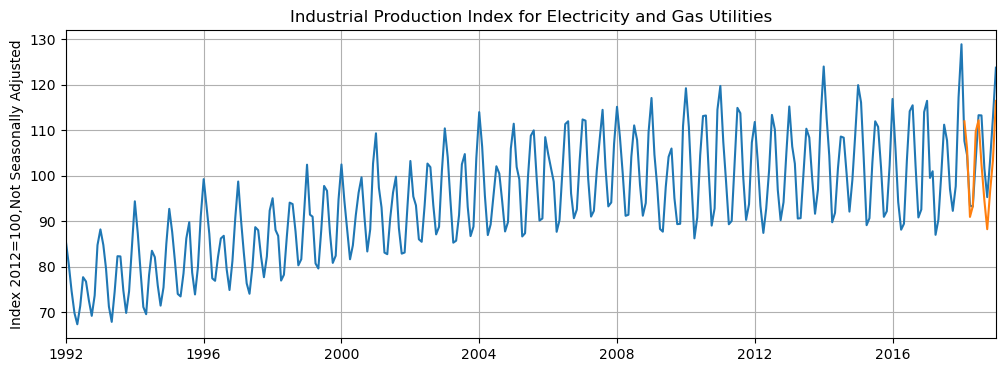

In [78]:
plt.figure(figsize=(12,4))
plt.title('Industrial Production Index for Electricity and Gas Utilities')
plt.ylabel('Index 2012=100,Not Seasonally Adjusted')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['IPG2211A2N'])
plt.plot(x,true_predictions)
plt.show()

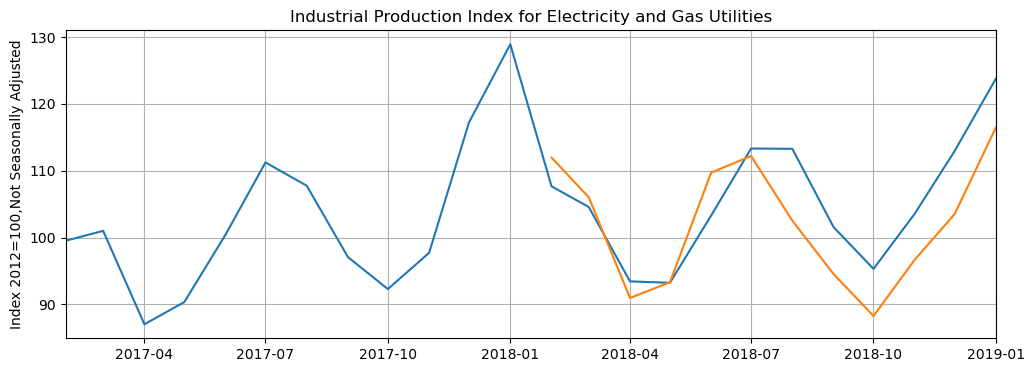

In [79]:
# DISPLAY THE END OF THE GRAPH
plt.figure(figsize=(12,4))
plt.title('Industrial Production Index for Electricity and Gas Utilities')
plt.ylabel('Index 2012=100,Not Seasonally Adjusted')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['IPG2211A2N'][-2*window_size:])
plt.plot(x,true_predictions)
plt.show()

## Great job!